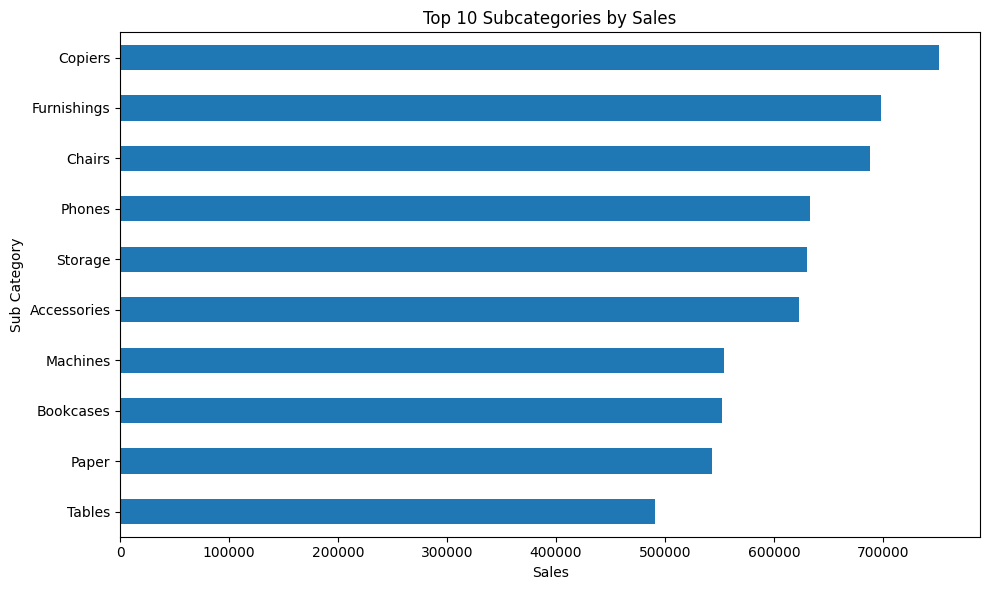

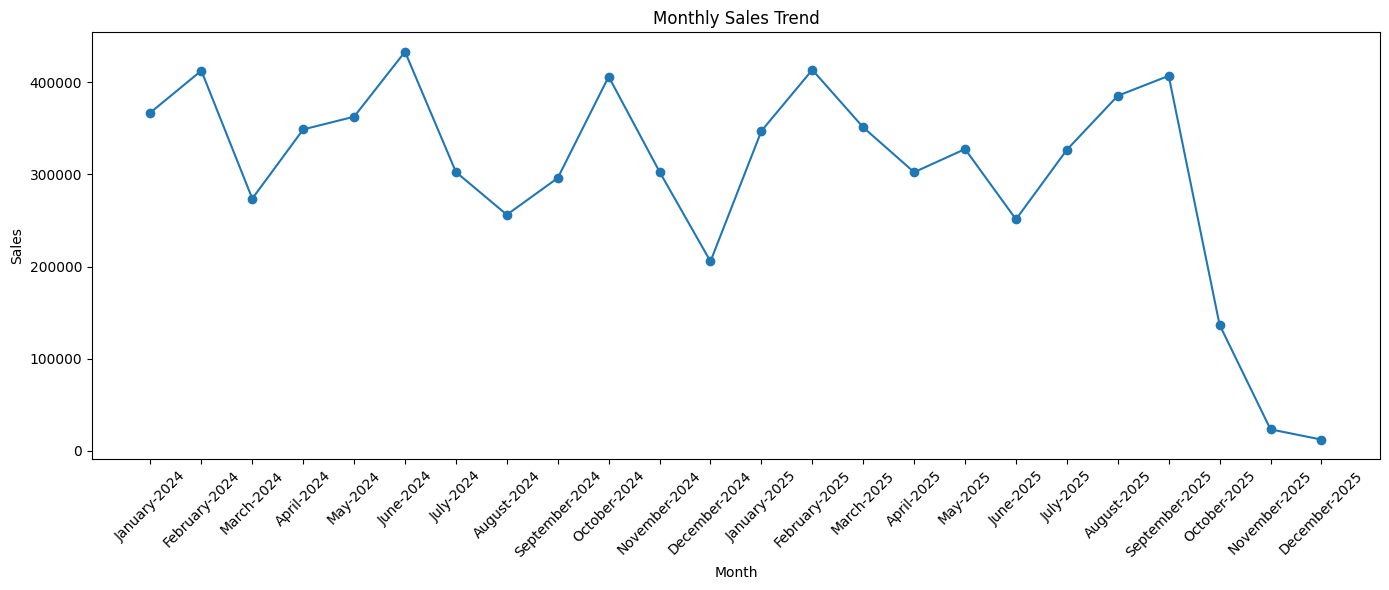

Charts saved successfully.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Read cleaned data
df = pd.read_excel("cleaned_orders.xlsx")

# Exclude cancelled orders and failed payments
valid_df = df[
    (~df["cancelled_order_flag"])
    &
    (~df["failed_payment_flag"])
]


# CHART 1 : Top 10 Subcategories by Sales


top_subcategories = (
    valid_df.groupby("sub_category")["calculated_sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))
top_subcategories.sort_values().plot(kind="barh")

plt.title("Top 10 Subcategories by Sales")
plt.xlabel("Sales")
plt.ylabel("Sub Category")
plt.tight_layout()

plt.savefig(
    "pivot_summary_1.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()



# CHART 2 : Monthly Sales Trend


monthly_sales = (
    valid_df.groupby(["order_year","order_month"])["calculated_sales"]
    .sum()
    .reset_index()
)

# Create proper order
month_order = [
    "January","February","March","April","May","June",
    "July","August","September","October","November","December"
]

monthly_sales["order_month"] = pd.Categorical(
    monthly_sales["order_month"],
    categories=month_order,
    ordered=True
)

monthly_sales = monthly_sales.sort_values(
    ["order_year","order_month"]
)

monthly_sales["period"] = (
    monthly_sales["order_month"].astype(str)
    + "-"
    + monthly_sales["order_year"].astype(str)
)

plt.figure(figsize=(14,6))

plt.plot(
    monthly_sales["period"],
    monthly_sales["calculated_sales"],
    marker="o"
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "pivot_summary_2.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Charts saved successfully.")